In [47]:
import numpy as np
import matplotlib.pyplot as plt

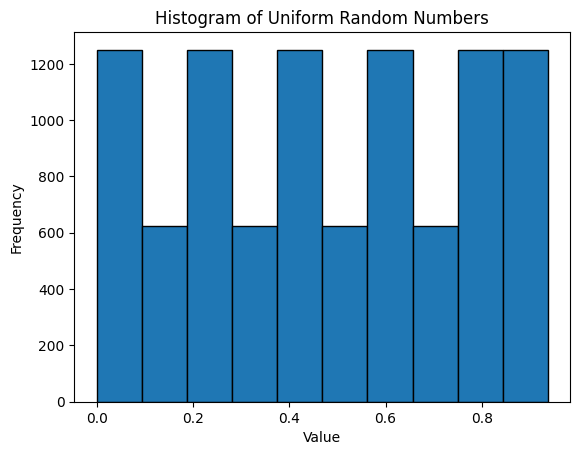

In [48]:
a = 5
c = 1
seed = 3  # Example seed value
m = 16 # 65536
n = 10000  # Number of random numbers to generate
bins = 10

class LCG:
    def __init__(self, seed, a=a, c=c, m=m):
        self.seed = seed
        self.a = a  # Degrees of freedom
        self.c = c
        self.m = m

    def next(self):
        """Generate the next random number starting from the current seed"""
        self.seed = (self.a * self.seed + self.c) % self.m
        return self.seed / self.m   # Normalize to [0, 1]
    
    def next_int(self):
        """Generate the next random integer starting from the current seed"""
        self.seed = (self.a * self.seed + self.c) % self.m
        return self.seed  # Return the raw integer value
    
    def next_n(self, n):
        """Generate the next n random numbers"""
        return [self.seed / self.m] + [self.next() for _ in range(n-1)]
    
    def next_n_int(self, n):
        """Generate the next n random integers"""
        return [self.seed] + [self.next_int() for _ in range(n-1)]




Generator = LCG(seed=seed, a=a, c=c, m=m)
nums = list(Generator.next_n(n))
nums_2 = list(Generator.next_n_int(n))

plt.hist(nums, bins=bins, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Uniform Random Numbers')
plt.show()


Descriptive tests

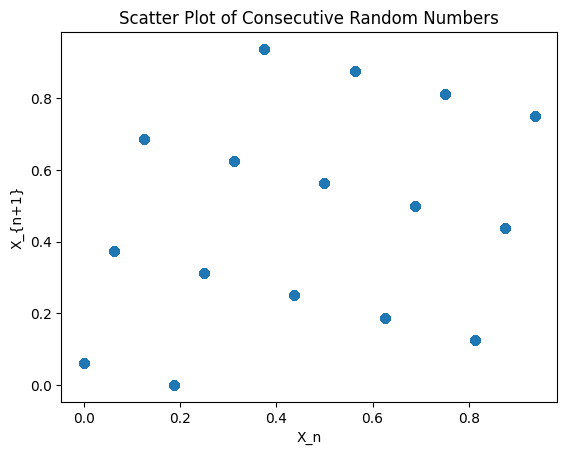

In [49]:
scatter_nums = np.array(nums)
plt.scatter(scatter_nums[:-1], scatter_nums[1:], alpha=0.5)
plt.xlabel('X_n')
plt.ylabel('X_{n+1}')
plt.title('Scatter Plot of Consecutive Random Numbers')
plt.show()

In [50]:
def chi_2_test(nums, bins=bins):
    """Perform a chi-squared test for uniformity"""
    observed, _ = np.histogram(nums, bins=bins)
    expected = len(nums) / bins
    chi_squared_stat = np.sum((observed - expected) ** 2 / expected)
    return chi_squared_stat

chi_squared_stat = chi_2_test(nums, bins=bins)
print(f"Chi-squared statistic: {chi_squared_stat}")

def chi_2_distribution(k):
    """Calculate the chi-squared distribution value for k degrees of freedom"""
    from scipy.stats import chi2
    return chi2.ppf(0.95, df=k)

k = bins - 1 # Degrees of freedom
chi_squared_critical = chi_2_distribution(k)
# print(f"Chi-squared critical value at 95% confidence: {chi_squared_critical}")
print(f"chi_squared_stat: {chi_squared_stat}, chi_squared_critical: {chi_squared_critical}")
if chi_squared_stat < chi_squared_critical:
    print("Fail to reject the null hypothesis: The numbers are uniformly distributed, meaning they are random.")
else:
    print("Reject the null hypothesis: The numbers are not uniformly distributed, meaning they are not random.")

Chi-squared statistic: 937.5
chi_squared_stat: 937.5, chi_squared_critical: 16.918977604620448
Reject the null hypothesis: The numbers are not uniformly distributed, meaning they are not random.


In [51]:
from scipy.stats import ksone

def kolomogorov_smirnov_test(nums, case):
    """Perform a Kolmogorov-Smirnov test for uniformity"""
    n = len(nums)
    sorted_nums = np.sort(nums)
    
    empirical_cdf = np.arange(1, n + 1) / n
    empirical_cdf_prev = np.arange(0, n) / n
    theoretical_cdf = sorted_nums  
    
    # Must check distance at both the top and bottom of the empirical steps
    D_plus = np.max(empirical_cdf - theoretical_cdf)
    D_minus = np.max(theoretical_cdf - empirical_cdf_prev)
    D = max(D_plus, D_minus)

    if case == 'known':
        adjusted_D = (np.sqrt(n) + 0.12 + 0.11 / np.sqrt(n)) * D
    if case == 'normal':
        adjusted_D = (np.sqrt(n) - 0.01 + 0.85 / np.sqrt(n)) * D
        return adjusted_D
    if case == 'exp':
        adjusted_D = (np.sqrt(n) + 0.26 + 0.05 / np.sqrt(n)) * (D - 0.2 / np.sqrt(n))
        return adjusted_D
    
    return D

def kolomogorov_smirnov_distribution(n):
    # To get the critical value
    return ksone.ppf(0.95, n)

D = kolomogorov_smirnov_test(nums, case='known')
D_critical = kolomogorov_smirnov_distribution(n)
print(f"Kolmogorov-Smirnov statistic: {D}")
print(f"Kolmogorov-Smirnov critical value at 95% confidence: {D_critical}")
if D < D_critical:
    print("The null hypothesis of uniformity cannot be rejected, the numbers are not random.")
else:    
    print("The null hypothesis of uniformity is rejected. The numbers are not random.")

Kolmogorov-Smirnov statistic: 0.0625
Kolmogorov-Smirnov critical value at 95% confidence: 0.012222011278849367
The null hypothesis of uniformity is rejected. The numbers are not random.


In [52]:
def wald_wolfowitz_runs_test(nums):
    """Perform the Wald-Wolfowitz runs test for randomness"""
    median = np.median(nums)
    runs = 1
    for i in range(1, len(nums)):
        if (nums[i] > median) != (nums[i-1] > median):
            runs += 1
    n1 = np.sum(nums > median) # upper half
    n2 = np.sum(nums <= median) # lower half
    
    expected_runs = 2 * n1 * n2 / (n1 + n2) + 1
    variance_runs = (expected_runs - 1) * (expected_runs - 2) / (n1 + n2 - 1)
    # print(f"Runs: {runs}, Expected Runs: {expected_runs}, Variance of Runs: {variance_runs}")
    # calculate the z-score which is 
    z = (runs - expected_runs) / np.sqrt(variance_runs)
    return z

z = wald_wolfowitz_runs_test(nums)
print(f"Wald-Wolfowitz runs test statistic (z): {z}")
if abs(z) < 1.96:  # 95% confidence interval
    print("Fail to reject the null hypothesis: The sequence is random.")
else:    
    print("Reject the null hypothesis: The sequence is not random.")

Wald-Wolfowitz runs test statistic (z): -25.0212512189641
Reject the null hypothesis: The sequence is not random.


In [53]:
# import numpy as np



In [54]:
def up_down_knuth_test(nums):

    T = 1
    run_length = []
    start = 1
    for i in range(1,len(nums)):
        if nums[i] < nums[i-1]:
            T += 1
            run_length.append(start)
            start = 1
        else:
            start += 1
    run_length.append(start)

    R = np.zeros(6)

    for r in run_length:
        if r >= 6:
            R[5] += 1
        else:
            R[r - 1] += 1

    
    n = len(nums)

    A = np.array([
    [4529.4, 9044.9, 13568, 18091, 22615, 27892],
    [9044.9, 18097, 27139, 36187, 45234, 55789],
    [13568, 27139, 40721, 54281, 67852, 83685],
    [18091, 36187, 54281, 72414, 90470, 111580],
    [22615, 45234, 67852, 90470, 113262, 139476],
    [27892, 55789, 83685, 111580, 139476, 172860]])

    B = np.array([1/6, 5/24, 11/120, 19/720, 29/5040, 1/840])

    D = (R - n * B)

    Z = 1/(n - 6) * (D.T @ A @ D)

    return Z


Z = up_down_knuth_test(nums)
print(f"Up-Down Knuth test statistic (Z): {Z}")
if Z < 11.07:  # Chi-squared critical value for 5 degrees of freedom at 95% confidence
    print("Fail to reject the null hypothesis: The sequence is random.")
else:    print("Reject the null hypothesis: The sequence is not random.")

    

Up-Down Knuth test statistic (Z): 1118.826845364202
Reject the null hypothesis: The sequence is not random.


In [55]:
import numpy as np

def up_down_knuth_test(nums):
    """Perform the Up-Down Knuth test for randomness"""
    up_down_sequence = [1 if nums[i] > nums[i-1] else 0 for i in range(1, len(nums))]
    # A run is a segment of identical signs
    if not up_down_sequence:
        return None

    runs = 1
    for i in range(1, len(up_down_sequence)):
        if up_down_sequence[i] != up_down_sequence[i-1]:
            runs += 1
    n = len(nums)

    expected_runs = (2 * n - 1) / 3
    variance_runs = (16 * n - 29) / 90
    # print(f"Runs: {runs}, Expected Runs: {expected_runs}, Variance of Runs: {variance_runs}, n: {n}")
    z = (runs - expected_runs) / np.sqrt(variance_runs)
    return z

z = up_down_knuth_test(nums)
print(f"Up-Down Knuth test statistic (z): {z}")
if abs(z) < 1.96:  # 95% confidence interval
    print("Fail to reject the null hypothesis: The sequence is random.")
else:    
    print("Reject the null hypothesis: The sequence is not random.")

Up-Down Knuth test statistic (z): -9.875106965999812
Reject the null hypothesis: The sequence is not random.


In [59]:
def correlation_test(nums, h=1):
    """Perform a correlation test for randomness"""
    n = len(nums)
    sum = 0
    for i in range(n - h):
        sum += nums[i] * nums[i + h]
    corr = sum / (n - h)

    expected_corr = 1/4
    expected_variance = 7/(144*n)
    # print(corr)
    z = (corr - expected_corr) / np.sqrt(expected_variance)
    return z

z = correlation_test(nums, h=1)
print(f"Correlation test statistic: {z}")
if abs(z) < 1.96:  # Threshold for correlation test (95% confidence)
    print("Fail to reject the null hypothesis: The sequence is random.")
else:    print("Reject the null hypothesis: The sequence is not random.")

Correlation test statistic: 1.4661098163791253
Fail to reject the null hypothesis: The sequence is random.


\begin{table}[H]
\centering
\begin{tabular}{l|ccccc}
          & $\chi^2$-test & KS-Test & Wald-Wolfowitz & Up-Down & Correlation  \\ \hline
Setting 1 & \cellcolor{failred}937.50 & \cellcolor{failred}0.0625 & \cellcolor{failred}-25.01 & \cellcolor{failred}-9.88 & \cellcolor{failred}23.92 \\
Setting 2 & \cellcolor{passgreen}8.40 & \cellcolor{passgreen}0.0086 & \cellcolor{passgreen}-0.05 & \cellcolor{passgreen}-0.05 & \cellcolor{passgreen}0.03 \\
Setting 3 & \cellcolor{passgreen}8.79 & \cellcolor{passgreen}0.0084 & \cellcolor{passgreen}-0.18 & \cellcolor{passgreen}0.03 & \cellcolor{passgreen}-0.15 \\
Setting 4 & \cellcolor{passgreen}1.62 & \cellcolor{passgreen}0.0030 & \cellcolor{passgreen}0.06 & \cellcolor{passgreen}-0.78 & \cellcolor{passgreen}-0.19 \\
\end{tabular}
\caption{Average test values across 100 seeds, with color indicators for pass/fail status.}
\label{table:test_values}
\end{table}



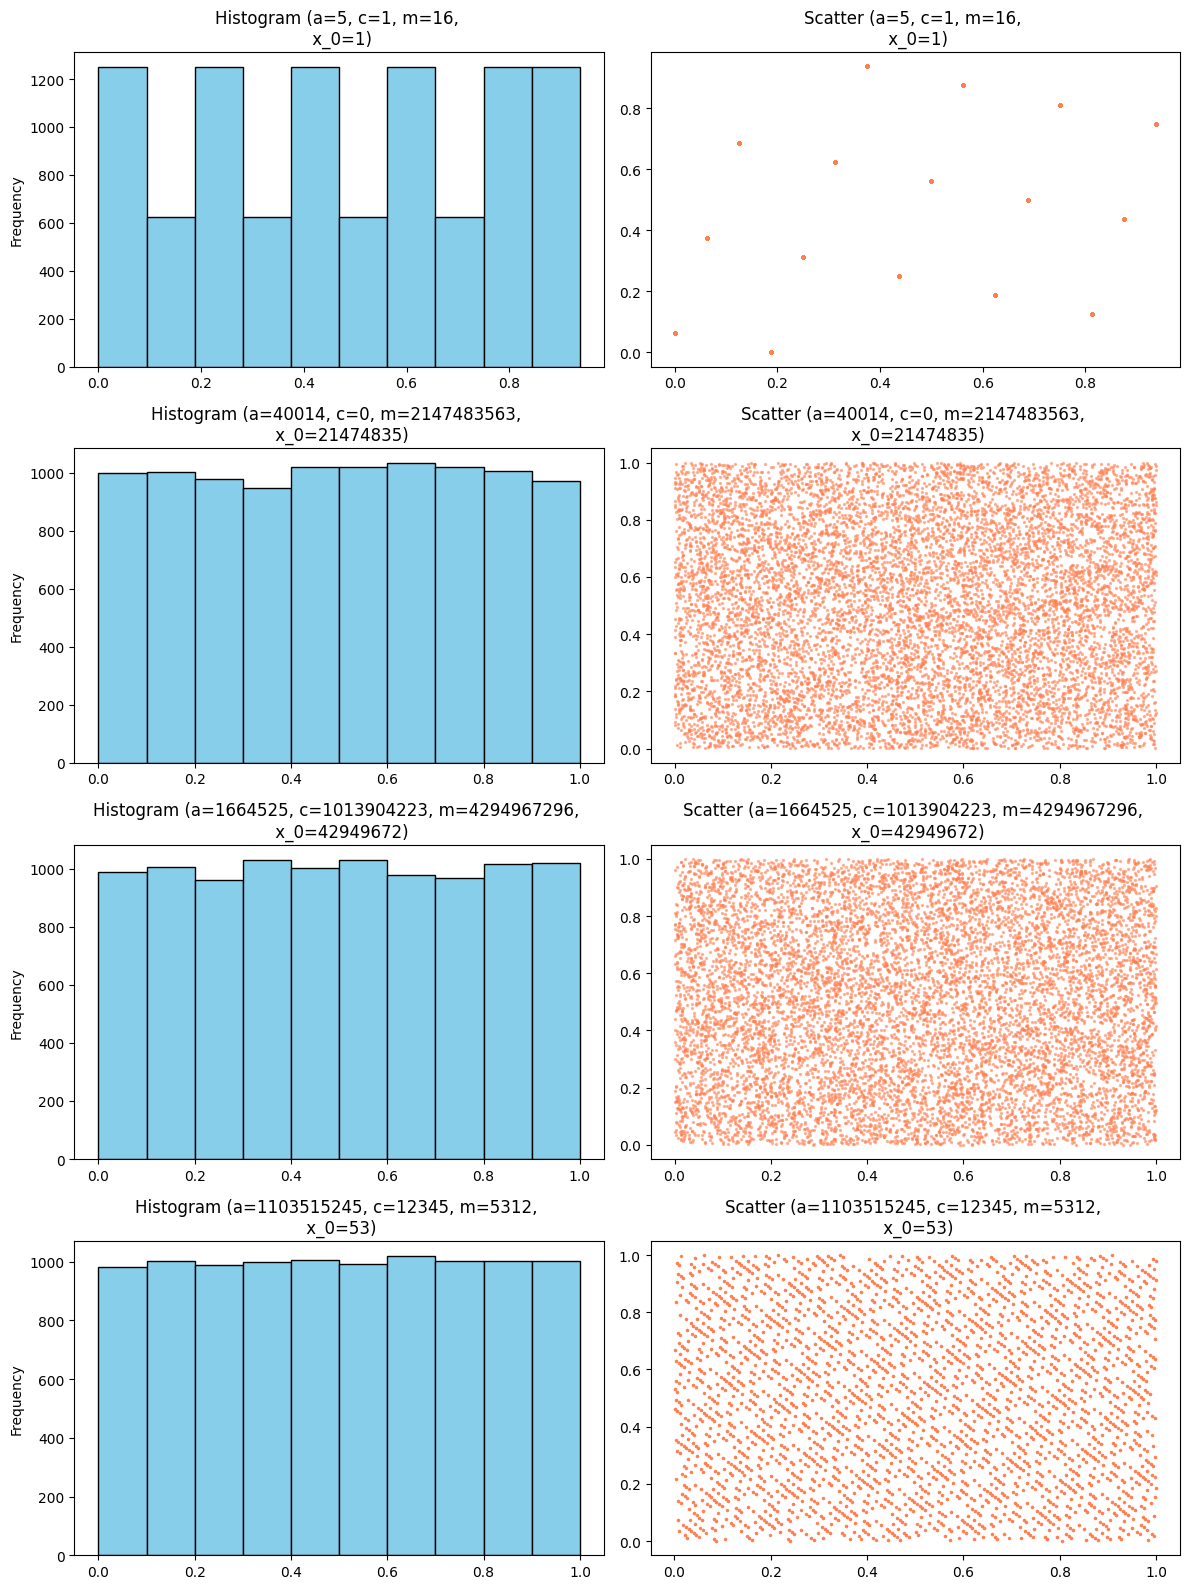

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Define different sets of parameters for the LCG
parameter_sets = [
    {'a': 5, 'c': 1, 'm': 16},
    {'a': 40014, 'c': 0, 'm': 2147483563},
    {'a': 1664525, 'c': 1013904223, 'm': 2**32},
    {'a': 1103515245, 'c': 12345, 'm': 5312}
]

n = 10000
bins_count = 10

# Create subplots setup
fig, axes = plt.subplots(len(parameter_sets), 2, figsize=(12, 4 * len(parameter_sets)))

# Print LaTeX Table Header
print("\\begin{table}[H]")
print("\\centering")
print("\\begin{tabular}{l|ccccc}")
print("          & $\\chi^2$-test & KS-Test & Wald-Wolfowitz & Up-Down & Correlation  \\\\ \\hline")

for i, params in enumerate(parameter_sets):
    m = params['m']
    
    # Cap the maximum number of runs to 100 or m-1 for small moduli
    num_runs = min(100, m - 1)
    
    # Calculate equidistant seeds
    step_size = max(1, m // num_runs)
    seeds = [(s * step_size) % m for s in range(1, num_runs + 1)]
    
    # Track sums for averages
    stats = {'chi2': 0, 'ks': 0, 'ww': 0, 'ud': 0, 'corr': 0}
    
    # Save the first run's data to maintain your original plotting style
    first_nums = None
    first_seed = seeds[0]
    
    for idx, seed in enumerate(seeds):
        gen = LCG(seed=int(seed), a=params['a'], c=params['c'], m=params['m'])
        nums = list(gen.next_n(n))
        
        if idx == 0:
            first_nums = nums
            
        # Run tests
        chi2 = chi_2_test(nums, bins=bins_count)
        ks = kolomogorov_smirnov_test(nums, case='known')
        ww = wald_wolfowitz_runs_test(nums)
        try:
            ud = up_down_knuth_test(nums)
        except NameError:
            ud = up_down_knuth_test(nums)
        corr = correlation_test(nums, h=16)
        
        # Accumulate statistics
        stats['chi2'] += chi2
        stats['ks'] += ks
        stats['ww'] += ww
        stats['ud'] += ud
        stats['corr'] += corr

    # Calculate averages
    avg_chi2 = stats['chi2'] / num_runs
    avg_ks = stats['ks'] / num_runs
    avg_ww = stats['ww'] / num_runs
    avg_ud = stats['ud'] / num_runs
    avg_corr = stats['corr'] / num_runs
    
    # Determine critical values
    chi2_crit = chi_2_distribution(bins_count - 1)
    ks_crit = kolomogorov_smirnov_distribution(n)
    
    # Helper function to format LaTeX cells
    def fmt_cell(val, passed, is_ks=False):
        color = "passgreen" if passed else "failred"
        # Print KS test with 4 decimals to match your example, others with 2
        if is_ks:
            return f"\\cellcolor{{{color}}}{val:.4f}"
        return f"\\cellcolor{{{color}}}{val:.2f}"

    # Determine pass/fail for the averages
    cell_chi2 = fmt_cell(avg_chi2, avg_chi2 < chi2_crit)
    cell_ks = fmt_cell(avg_ks, avg_ks < ks_crit, is_ks=True)
    cell_ww = fmt_cell(avg_ww, abs(avg_ww) < 1.96)
    cell_ud = fmt_cell(avg_ud, abs(avg_ud) < 1.96)
    cell_corr = fmt_cell(avg_corr, abs(avg_corr) < 1.96)
    
    # Print the LaTeX row for this setting
    print(f"Setting {i+1} & {cell_chi2} & {cell_ks} & {cell_ww} & {cell_ud} & {cell_corr} \\\\")
    
    # Plot 1: Histogram (using the first seed's sequence)
    axes[i, 0].hist(first_nums, bins=bins_count, edgecolor='black', color='skyblue')
    axes[i, 0].set_title(f"Histogram (a={params['a']}, c={params['c']}, m={params['m']}, \n x_0={first_seed})")
    axes[i, 0].set_ylabel('Frequency')
    
    # Plot 2: Scatter plot of consecutive values (using the first seed's sequence)
    scatter_nums = np.array(first_nums)
    axes[i, 1].scatter(scatter_nums[:-1], scatter_nums[1:], alpha=0.5, s=2, color='coral')
    axes[i, 1].set_title(f"Scatter (a={params['a']}, c={params['c']}, m={params['m']}, \n x_0={first_seed})")

# Print LaTeX Table Footer
print("\\end{tabular}")
print("\\caption{Average test values across 100 seeds, with color indicators for pass/fail status.}")
print("\\label{table:test_values}")
print("\\end{table}\n")

plt.tight_layout()
plt.savefig("lcg_comparison.png")
plt.show()


\begin{table}[H]
\centering
\begin{tabular}{l|ccccc}
          & $\chi^2$-test & KS-Test & Wald-Wolfowitz & Up-Down & Correlation  \\ \hline
Numpy Generator (seed 42) & \cellcolor{passgreen}9.19 & \cellcolor{passgreen}0.0088 & \cellcolor{passgreen}-0.06 & \cellcolor{passgreen}-0.04 & \cellcolor{passgreen}0.12\\
\end{tabular}
\caption{Test values with using numpy generator, with color indicators for pass/fail status.}
\label{table:numpy_test}
\end{table}



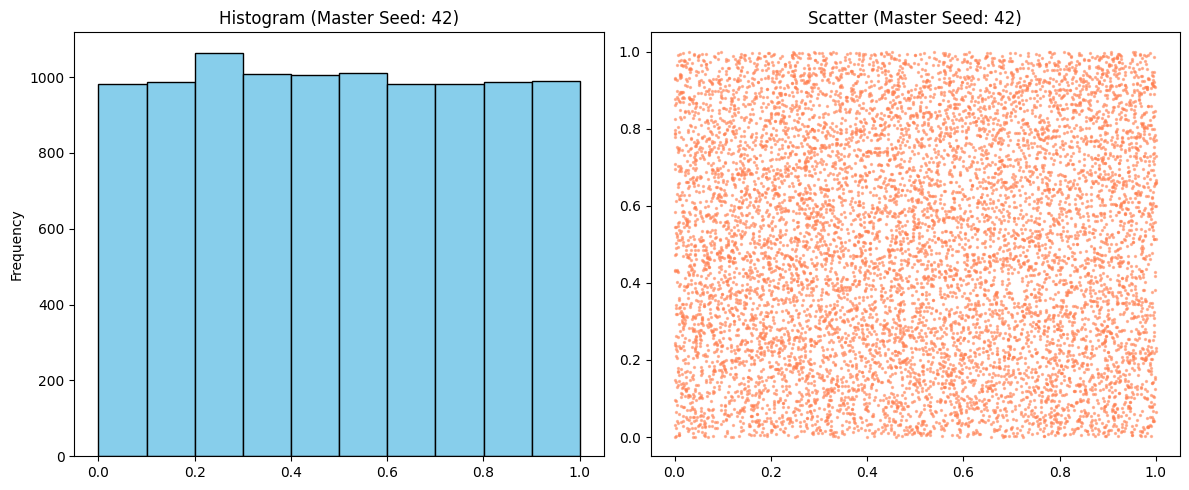

In [62]:
import matplotlib.pyplot as plt
import numpy as np

n = 10000
bins_count = 10

# Set up the SeedSequence for NumPy with master seed 42
master_seed = 42
ss = np.random.SeedSequence(master_seed)
num_runs = 100

# Spawn 100 distinct child seeds for independent parallel streams
child_seeds = ss.spawn(num_runs)

# Track sums for averages
stats = {'chi2': 0, 'ks': 0, 'ww': 0, 'ud': 0, 'corr': 0}

# Save the first run's data for plotting
first_nums = None

for idx in range(num_runs):
    # Initialize a new Generator using the child seed
    rng = np.random.default_rng(child_seeds[idx])
    nums = rng.random(n)
    
    if idx == 0:
        first_nums = nums
        
    # Run tests
    chi2 = chi_2_test(nums)
    ks = kolomogorov_smirnov_test(nums, case='known')
    ww = wald_wolfowitz_runs_test(nums)
    try:
        ud = up_down_knuth_test(nums)
    except NameError:
        ud = up_down_knuth_test(nums)
    corr = correlation_test(nums, h=5)
    
    # Accumulate statistics
    stats['chi2'] += chi2
    stats['ks'] += ks
    stats['ww'] += ww
    stats['ud'] += ud
    stats['corr'] += corr

# Calculate averages
avg_chi2 = stats['chi2'] / num_runs
avg_ks = stats['ks'] / num_runs
avg_ww = stats['ww'] / num_runs
avg_ud = stats['ud'] / num_runs
avg_corr = stats['corr'] / num_runs

# Determine critical values (assuming 9 degrees of freedom for chi2 with 10 bins)
chi2_crit = chi_2_distribution(9)
ks_crit = kolomogorov_smirnov_distribution(n)

# Helper function to format LaTeX cells with pass/fail colors
def fmt_cell(val, passed, is_ks=False):
    color = "passgreen" if passed else "failred"
    if is_ks:
        return f"\\cellcolor{{{color}}}{val:.4f}"
    return f"\\cellcolor{{{color}}}{val:.2f}"

# Determine pass/fail for the averages
cell_chi2 = fmt_cell(avg_chi2, avg_chi2 < chi2_crit)
cell_ks = fmt_cell(avg_ks, avg_ks < ks_crit, is_ks=True)
cell_ww = fmt_cell(avg_ww, abs(avg_ww) < 1.96)
cell_ud = fmt_cell(avg_ud, abs(avg_ud) < 1.96)
cell_corr = fmt_cell(avg_corr, abs(avg_corr) < 1.96)

# Output the LaTeX Table
print("\\begin{table}[H]")
print("\\centering")
print("\\begin{tabular}{l|ccccc}")
print("          & $\\chi^2$-test & KS-Test & Wald-Wolfowitz & Up-Down & Correlation  \\\\ \\hline")
print(f"Numpy Generator (seed {master_seed}) & {cell_chi2} & {cell_ks} & {cell_ww} & {cell_ud} & {cell_corr}\\\\")
print("\\end{tabular}")
print("\\caption{Test values with using numpy generator, with color indicators for pass/fail status.}")
print("\\label{table:numpy_test}")
print("\\end{table}\n")

# Plot 1: Histogram (Using first run's data)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(first_nums, bins=bins_count, edgecolor='black', color='skyblue')
plt.title(f"Histogram (Master Seed: {master_seed})")
plt.ylabel('Frequency')

# Plot 2: Scatter plot of consecutive values (Using first run's data)
scatter_nums = np.array(first_nums)
plt.subplot(1, 2, 2)
plt.scatter(scatter_nums[:-1], scatter_nums[1:], alpha=0.5, s=2, color='coral')
plt.title(f"Scatter (Master Seed: {master_seed})")

plt.tight_layout()
plt.savefig("lcg_comparison_numpy.png")
plt.show()
